<a href="https://colab.research.google.com/github/GScaramussa/Redes/blob/main/Trabalho3redes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Progresso: 10.0%
Progresso: 20.0%
Progresso: 30.0%
Progresso: 40.0%
Progresso: 50.0%
Progresso: 60.0%
Progresso: 70.0%
Progresso: 80.0%
Progresso: 90.0%
Progresso: 100.0%
Tempo de execução: 8.617 s
Progresso: 10.0%
Progresso: 20.0%
Progresso: 30.0%
Progresso: 40.0%
Progresso: 50.0%
Progresso: 60.0%
Progresso: 70.0%
Progresso: 80.0%
Progresso: 90.0%
Progresso: 100.0%
Tempo de execução: 3.665 s
Progresso: 10.0%
Progresso: 20.0%
Progresso: 30.0%
Progresso: 40.0%
Progresso: 50.0%
Progresso: 60.0%
Progresso: 70.0%
Progresso: 80.0%
Progresso: 90.0%
Progresso: 100.0%
Tempo de execução: 4.785 s
Progresso: 10.0%
Progresso: 20.0%
Progresso: 30.0%
Progresso: 40.0%
Progresso: 50.0%
Progresso: 60.0%
Progresso: 70.0%
Progresso: 80.0%
Progresso: 90.0%
Progresso: 100.0%
Tempo de execução: 3.616 s
Progresso: 10.0%
Progresso: 20.0%
Progresso: 30.0%
Progresso: 40.0%
Progresso: 50.0%
Progresso: 60.0%
Progresso: 70.0%
Progresso: 80.0%
Progresso: 90.0%
Progresso: 100.0%
Tempo de execução: 3.562 s


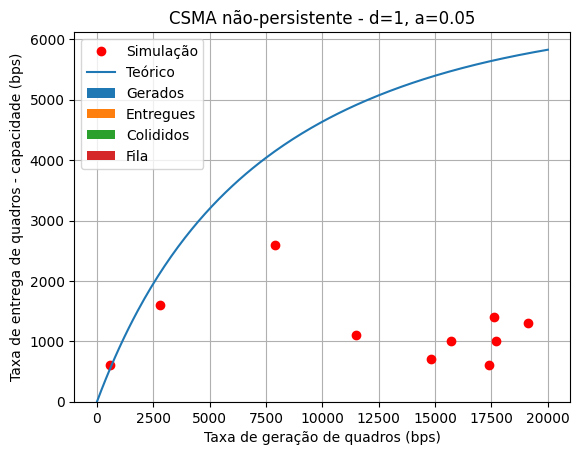

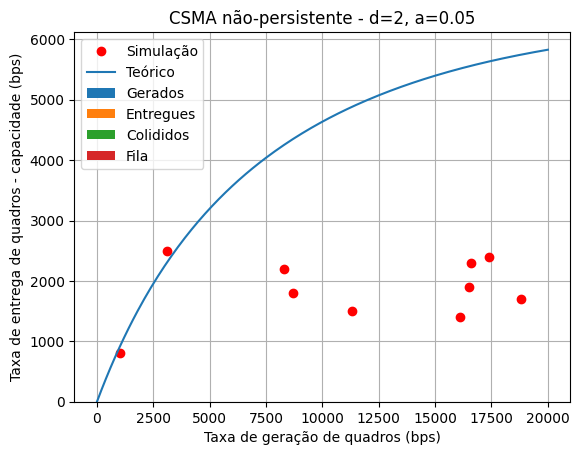

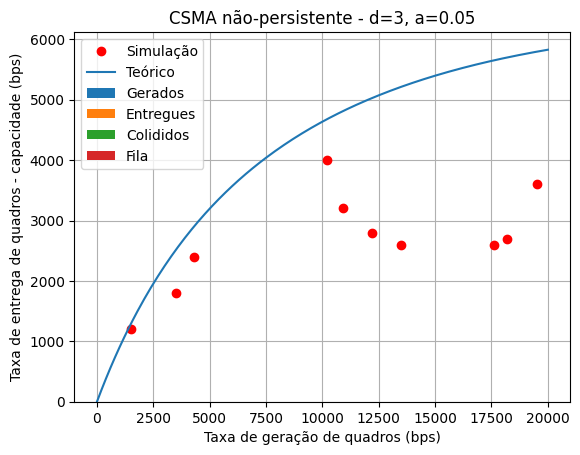

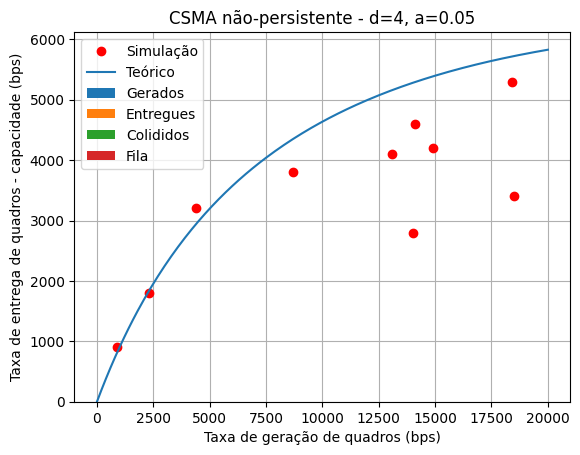

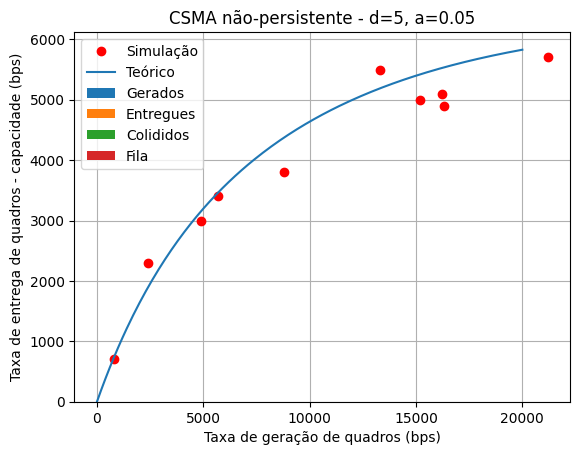

In [1]:
import math
import time
import numpy as np
import matplotlib.pyplot as plt


def simular_csma_nao_persistente():
    # PARÂMETROS DE SIMULAÇÃO
    # simulação do protocolo CSMA não-persistente

    # tempo total da simulação em segundos
    tempo = 1

    # número total de estações
    n_est = 10

    # taxa de transmissão do meio em bits por segundo
    taxa_bits = 1e4

    # tamanho do quadro em bits
    tam_quadro = 100

    # tempo de transmissão do quadro em segundos
    t_quadro = tam_quadro / taxa_bits

    # intervalo de tempo da simulação
    dt_sim = t_quadro / tam_quadro

    # tempo total da simulação em instantes
    t_sim = math.ceil(tempo / dt_sim)

    # taxa média máxima de chegada de quadros por segundo para cada estação
    taxa_max_quadro = math.ceil(taxa_bits / tam_quadro / n_est)

    tam_q = math.ceil(tam_quadro / taxa_bits / dt_sim)

    # variação da taxa de geração de quadros
    pontos = 10
    taxas_quadro = taxa_max_quadro * np.arange(1 / pontos, 1 + 1 / pontos, 1 / pontos)

    fig = 1

    for d in range(1, 6):
        for a in [0.05]:

            # resultados da simulação
            quadros_transmitidos = np.zeros(pontos)
            quadros_entregues = np.zeros(pontos)
            quadros_gerados = np.zeros(pontos)
            quadros_colididos = np.zeros(pontos)
            quadros_bloqueados = np.zeros(pontos)
            quadros_fila = np.zeros(pontos)

            inicio = time.time()

            for taxa_idx in range(pontos):
                taxa_quadro = taxas_quadro[taxa_idx]

                print(f"Progresso: {100 * (taxa_idx + 1) / pontos:.1f}%")

                tm_q = taxa_quadro * dt_sim

                # janela de tempo de espera aleatório em número de instantes
                espera_max = 10 * tam_quadro

                # número de repetições da simulação - para tirar a média
                rodadas = 1

                for _ in range(rodadas):
                    # VARIÁVEIS DOS EVENTOS
                    tx_ativo = np.zeros(n_est, dtype=int)       # transmissores ativos
                    tx_fila = np.zeros(n_est, dtype=int)        # fila de quadros do transmissor
                    tx_cnt = np.zeros(n_est, dtype=int)         # contador de progresso do transmissor
                    colis = np.zeros(t_sim, dtype=int)          # armazenador de colisões
                    colin = np.zeros(n_est, dtype=int)          # índices das estações com colisão
                    tx_espera = np.zeros(n_est, dtype=int)      # espera aleatória
                    transmis = np.zeros((n_est, t_sim), dtype=int)  # transmissões
                    chegada_quadros = 0
                    colisoes = 0
                    entregues = 0
                    bloqueios = 0
                    tx_ativo_atr = np.zeros(n_est, dtype=int)

                    # atraso de propagação
                    atraso = math.ceil(a * tam_quadro / taxa_bits / dt_sim)

                    for k in range(t_sim):
                        # guarda o estado do meio com atraso
                        if k >= atraso:
                            tx_ativo_atr = transmis[:, k - atraso].copy()

                        for j in range(n_est):
                            # verificar se o transmissor está ativo
                            if tx_ativo[j] == 1:
                                transmis[j, k] = 1

                            # simulação dos nós ocultos
                            # em MATLAB:
                            # jo = [1:n_est]; jo = [jo(end-d+1:end), jo, jo(1:d)];
                            # jo = jo(j:j+2*d);
                            base = list(range(n_est))
                            jo_expandido = base[-d:] + base + base[:d]
                            jo = jo_expandido[j:j + 2 * d + 1]

                            # verificar se o quadro foi enviado
                            if tx_cnt[j] > 0:
                                tx_cnt[j] -= 1
                                if tx_cnt[j] == 0:
                                    tx_ativo[j] = 0

                                    # verificar se a transmissão sofreu colisão
                                    if colin[j] == 1:
                                        tx_espera[j] = math.ceil(espera_max * np.random.rand())
                                        tx_fila[j] += 1
                                        colin[j] = 0
                                        colisoes += 1
                                    else:
                                        entregues += 1

                            else:
                                # verificar se tem quadros em espera e se o meio está livre
                                if tx_fila[j] > 0:
                                    meio_ocupado = np.count_nonzero(tx_ativo_atr[jo]) > 0

                                    if tx_espera[j] == 0 and not meio_ocupado:
                                        tx_ativo[j] = 1
                                        tx_cnt[j] = tam_q
                                        tx_fila[j] -= 1

                                    elif tx_espera[j] > 0:
                                        tx_espera[j] -= 1

                                    elif meio_ocupado:
                                        # meio ocupado - modo não-persistente
                                        tx_espera[j] = math.ceil(espera_max * np.random.rand())
                                        bloqueios += 1

                            # verificar se chegou um novo quadro
                            p_novo = np.random.rand()
                            if p_novo < tm_q:
                                chegada_quadros += 1
                                meio_ocupado = np.count_nonzero(tx_ativo_atr[jo]) > 0

                                if tx_ativo[j] == 0 and tx_espera[j] == 0 and not meio_ocupado:
                                    tx_ativo[j] = 1
                                    tx_cnt[j] = tam_q
                                else:
                                    tx_fila[j] += 1
                                    if tx_espera[j] == 0 and meio_ocupado:
                                        tx_espera[j] = math.ceil(espera_max * np.random.rand())
                                        bloqueios += 1

                        # verifica se houve colisão
                        if np.count_nonzero(tx_ativo) > 1:
                            colis[k] = 1
                            colin = tx_ativo.copy()

                    quadros_transmitidos[taxa_idx] += (chegada_quadros - np.sum(tx_fila)) / rodadas
                    quadros_entregues[taxa_idx] += entregues / rodadas
                    quadros_gerados[taxa_idx] += chegada_quadros / rodadas
                    quadros_colididos[taxa_idx] += colisoes / rodadas
                    quadros_bloqueados[taxa_idx] += bloqueios / rodadas
                    quadros_fila[taxa_idx] += np.sum(tx_fila) / rodadas

            fim = time.time()
            print(f"Tempo de execução: {fim - inicio:.3f} s")

            # CSMA não-persistente teórico
            G = np.arange(0, 2.01, 0.01)

            # evitar divisão problemática em G=0
            numerador = G * np.exp(-a * G)
            denominador = G * (1 + 2 * a) + np.exp(-a * G)
            S = np.divide(numerador, denominador, out=np.zeros_like(numerador), where=denominador != 0)

            # Gráfico de barras
            plt.figure()
            dados_barra = np.column_stack([
                quadros_gerados,
                quadros_entregues,
                quadros_colididos,
                quadros_fila
            ])
            plt.bar(np.arange(pontos) - 0.3, dados_barra[:, 0], width=0.2, label="Gerados")
            plt.bar(np.arange(pontos) - 0.1, dados_barra[:, 1], width=0.2, label="Entregues")
            plt.bar(np.arange(pontos) + 0.1, dados_barra[:, 2], width=0.2, label="Colididos")
            plt.bar(np.arange(pontos) + 0.3, dados_barra[:, 3], width=0.2, label="Fila")
            plt.legend()
            plt.title(f"Resultados por carga - d={d}, a={a}")
            plt.xlabel("Índice da taxa")
            plt.ylabel("Quantidade de quadros")

            # Curva simulada x teórica
            plt.figure(fig)
            fig += 1
            x_sim = (quadros_colididos + quadros_entregues + quadros_bloqueados) * tam_quadro / tempo
            y_sim = quadros_entregues * tam_quadro / tempo

            plt.plot(x_sim, y_sim, 'ro', label='Simulação')
            plt.plot(G * taxa_bits, S * taxa_bits, '-', label='Teórico')
            plt.grid(True)
            plt.xlabel('Taxa de geração de quadros (bps)')
            plt.ylabel('Taxa de entrega de quadros - capacidade (bps)')
            plt.title(f'CSMA não-persistente - d={d}, a={a}')
            plt.legend()

    plt.show()


if __name__ == "__main__":
    simular_csma_nao_persistente()

# Relatório – Problema da estação oculta e solução com MACA/CSMA/CA

Nesta prática foi possível observar o efeito do problema da estação oculto no desempenho do protocolo CSMA. Na simulação, nem todas as estações conseguem escutar umas às outras, o que faz com que duas ou mais estações possam interpretar o meio como livre ao mesmo tempo e iniciar transmissões simultâneas. Quando isso acontece, ocorre colisão, reduzindo a eficiência da comunicação. O objetivo da atividade é justamente observar esse efeito e discutir o uso de MACA ou CSMA/CA como forma de solução.

O principal efeito observado é o aumento de retransmissões, bloqueios e quadros acumulados na fila, o que reduz a taxa de entrega de quadros à medida que a carga da rede aumenta. Embora o gráfico principal da simulação não mostre uma curva específica de colisões, isso não significa que elas não ocorram. No código, as colisões são detectadas e contabilizadas, mas o gráfico destacado compara principalmente a taxa de entrega obtida na simulação com a curva teórica, deixando as colisões implícitas no comportamento geral do sistema. Já a lógica de nós ocultos e a contagem de colisões estão implementadas diretamente no programa.

Uma forma de resolver esse problema é utilizar o protocolo MACA ou o CSMA/CA. Esses protocolos procuram evitar colisões antes que elas aconteçam. No MACA, por exemplo, a estação que deseja transmitir envia primeiro um quadro RTS (*Request to Send*). Se o receptor estiver disponível, ele responde com um CTS (*Clear to Send*). Ao ouvir esse CTS, as outras estações entendem que o meio está reservado e aguardam antes de tentar transmitir.

Esse mecanismo é eficiente porque, mesmo que duas estações não consigam se escutar diretamente, elas ainda podem perceber que o canal será utilizado por meio dos quadros de controle. Assim, diminui-se a chance de colisões causadas por estações ocultas. No CSMA/CA, essa ideia também pode ser complementada com espera aleatória e com uma variável de reserva do meio, como o NAV, aumentando ainda mais a eficiência da transmissão. O próprio roteiro da atividade sugere essa abordagem para modificar a simulação e comparar os resultados com o CSMA convencional.

Portanto, o problema da estação oculta prejudica o funcionamento do CSMA ao aumentar conflitos de transmissão e reduzir a capacidade efetiva de entrega de dados. O uso de MACA ou CSMA/CA melhora esse cenário ao criar um mecanismo de coordenação entre as estações, permitindo transmissões mais organizadas e com menor probabilidade de colisão.

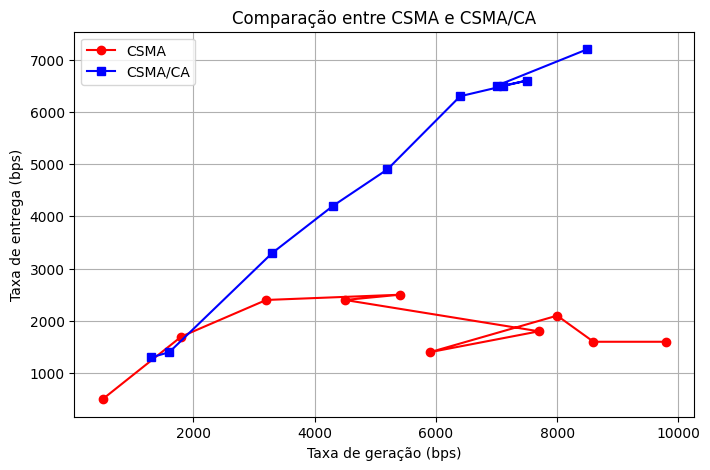

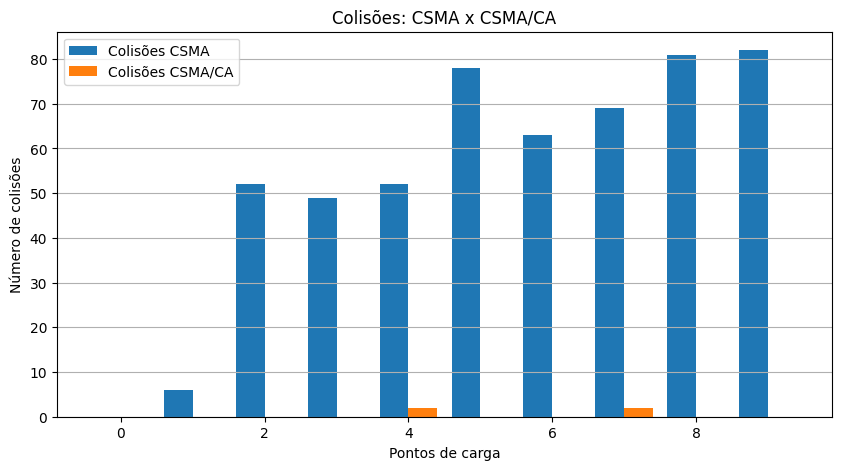

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# =========================
# PARÂMETROS
# =========================
tempo = 1.0
n_est = 10
taxa_bits = 1e4
tam_quadro = 100
t_quadro = tam_quadro / taxa_bits
dt_sim = t_quadro / tam_quadro
t_sim = int(np.ceil(tempo / dt_sim))

taxa_max_quadro = int(np.ceil(taxa_bits / tam_quadro / n_est))
tam_q = int(np.ceil(tam_quadro / taxa_bits / dt_sim))

pontos = 10
taxas_quadro = taxa_max_quadro * np.arange(1, pontos + 1) / pontos

a = 0.05   # atraso normalizado
d = 2      # alcance de escuta (para nós ocultos)
espera_max = 10 * tam_quadro


# =========================
# FUNÇÕES AUXILIARES
# =========================
def vizinhos_circulares(j, d, n):
    return [((j + k) % n) for k in range(-d, d + 1)]

def simular_csma(tm_q):
    tx_ativo = np.zeros(n_est, dtype=int)
    tx_fila = np.zeros(n_est, dtype=int)
    tx_cnt = np.zeros(n_est, dtype=int)
    colin = np.zeros(n_est, dtype=int)
    tx_espera = np.zeros(n_est, dtype=int)
    transmis = np.zeros((n_est, t_sim), dtype=int)

    gerados = entregues = colisoes = bloqueios = 0
    atraso = int(np.ceil(a * tam_quadro / taxa_bits / dt_sim))

    for k in range(t_sim):
        tx_ativo_atr = transmis[:, k - atraso] if k > atraso else np.zeros(n_est, dtype=int)

        for j in range(n_est):
            jo = vizinhos_circulares(j, d, n_est)

            if tx_ativo[j]:
                transmis[j, k] = 1

            if tx_cnt[j] > 0:
                tx_cnt[j] -= 1
                if tx_cnt[j] == 0:
                    tx_ativo[j] = 0
                    if colin[j]:
                        tx_espera[j] = np.random.randint(1, espera_max + 1)
                        tx_fila[j] += 1
                        colin[j] = 0
                        colisoes += 1
                    else:
                        entregues += 1
            else:
                if tx_fila[j] > 0:
                    if tx_espera[j] == 0 and np.sum(tx_ativo_atr[jo]) == 0:
                        tx_ativo[j] = 1
                        tx_cnt[j] = tam_q
                        tx_fila[j] -= 1
                    elif tx_espera[j] > 0:
                        tx_espera[j] -= 1
                    else:
                        tx_espera[j] = np.random.randint(1, espera_max + 1)
                        bloqueios += 1

            if np.random.rand() < tm_q:
                gerados += 1
                if tx_ativo[j] == 0 and tx_espera[j] == 0 and np.sum(tx_ativo_atr[jo]) == 0:
                    tx_ativo[j] = 1
                    tx_cnt[j] = tam_q
                else:
                    tx_fila[j] += 1
                    if tx_espera[j] == 0 and np.sum(tx_ativo_atr[jo]) > 0:
                        tx_espera[j] = np.random.randint(1, espera_max + 1)
                        bloqueios += 1

        if np.sum(tx_ativo) > 1:
            colin = tx_ativo.copy()

    return gerados, entregues, colisoes, bloqueios, np.sum(tx_fila)


def simular_csma_ca(tm_q):
    tx_ativo = np.zeros(n_est, dtype=int)
    tx_fila = np.zeros(n_est, dtype=int)
    tx_cnt = np.zeros(n_est, dtype=int)
    tx_espera = np.zeros(n_est, dtype=int)
    transmis = np.zeros((n_est, t_sim), dtype=int)
    nav = np.zeros(n_est, dtype=int)

    gerados = entregues = colisoes = bloqueios = 0
    atraso = int(np.ceil(a * tam_quadro / taxa_bits / dt_sim))

    # destino em anel: j -> j+1
    dst = np.array([(j + 1) % n_est for j in range(n_est)])

    for k in range(t_sim):
        tx_ativo_atr = transmis[:, k - atraso] if k > atraso else np.zeros(n_est, dtype=int)

        nav[nav > 0] -= 1
        req = np.zeros(n_est, dtype=int)

        for j in range(n_est):
            jo = vizinhos_circulares(j, d, n_est)

            if tx_ativo[j]:
                transmis[j, k] = 1

            if tx_cnt[j] > 0:
                tx_cnt[j] -= 1
                if tx_cnt[j] == 0:
                    tx_ativo[j] = 0
                    entregues += 1
            else:
                if tx_espera[j] > 0:
                    tx_espera[j] -= 1

            if np.random.rand() < tm_q:
                gerados += 1
                tx_fila[j] += 1

            if (tx_ativo[j] == 0 and tx_fila[j] > 0 and tx_espera[j] == 0
                and nav[j] == 0 and np.sum(tx_ativo_atr[jo]) == 0):
                req[j] = 1
            elif (tx_ativo[j] == 0 and tx_fila[j] > 0 and tx_espera[j] == 0
                  and (nav[j] > 0 or np.sum(tx_ativo_atr[jo]) > 0)):
                tx_espera[j] = np.random.randint(1, espera_max + 1)
                bloqueios += 1

        sucesso = np.zeros(n_est, dtype=int)

        for j in np.where(req == 1)[0]:
            r = dst[j]
            area_j = set(vizinhos_circulares(j, d, n_est) + vizinhos_circulares(r, d, n_est) + [j, r])

            conflito = False
            for i in np.where(req == 1)[0]:
                if i == j:
                    continue
                ri = dst[i]
                area_i = set(vizinhos_circulares(i, d, n_est) + vizinhos_circulares(ri, d, n_est) + [i, ri])
                if area_j & area_i:
                    conflito = True
                    break

            if not conflito:
                sucesso[j] = 1

        for j in np.where(sucesso == 1)[0]:
            r = dst[j]
            area = list(set(vizinhos_circulares(j, d, n_est) + vizinhos_circulares(r, d, n_est) + [j, r]))
            tx_ativo[j] = 1
            tx_cnt[j] = tam_q
            tx_fila[j] -= 1
            nav[area] = np.maximum(nav[area], tam_q)

        for j in np.where((req == 1) & (sucesso == 0))[0]:
            tx_espera[j] = np.random.randint(1, espera_max + 1)
            colisoes += 1

    return gerados, entregues, colisoes, bloqueios, np.sum(tx_fila)


# =========================
# SIMULAÇÃO
# =========================
ger_csma, ent_csma = [], []
col_csma, blo_csma, fila_csma = [], [], []

ger_ca, ent_ca = [], []
col_ca, blo_ca, fila_ca = [], [], []

for taxa_quadro in taxas_quadro:
    tm_q = taxa_quadro * dt_sim

    g, e, c, b, f = simular_csma(tm_q)
    ger_csma.append(g)
    ent_csma.append(e)
    col_csma.append(c)
    blo_csma.append(b)
    fila_csma.append(f)

    g, e, c, b, f = simular_csma_ca(tm_q)
    ger_ca.append(g)
    ent_ca.append(e)
    col_ca.append(c)
    blo_ca.append(b)
    fila_ca.append(f)

# converter para bps
x_csma = np.array(ger_csma) * tam_quadro / tempo
y_csma = np.array(ent_csma) * tam_quadro / tempo

x_ca = np.array(ger_ca) * tam_quadro / tempo
y_ca = np.array(ent_ca) * tam_quadro / tempo

# =========================
# GRÁFICOS
# =========================
plt.figure(figsize=(8,5))
plt.plot(x_csma, y_csma, 'o-r', label='CSMA')
plt.plot(x_ca, y_ca, 's-b', label='CSMA/CA')
plt.grid(True)
plt.xlabel('Taxa de geração (bps)')
plt.ylabel('Taxa de entrega (bps)')
plt.title('Comparação entre CSMA e CSMA/CA')
plt.legend()
plt.show()

plt.figure(figsize=(10,5))
plt.bar(np.arange(pontos)-0.2, col_csma, width=0.4, label='Colisões CSMA')
plt.bar(np.arange(pontos)+0.2, col_ca, width=0.4, label='Colisões CSMA/CA')
plt.grid(True, axis='y')
plt.xlabel('Pontos de carga')
plt.ylabel('Número de colisões')
plt.title('Colisões: CSMA x CSMA/CA')
plt.legend()
plt.show()

No CSMA, estações ocultas podem transmitir ao mesmo tempo porque nem sempre
escutam umas às outras, o que aumenta colisões. No CSMA/CA, o uso de RTS/CTS
instantâneos e da variável NAV reserva logicamente o meio antes da transmissão
dos dados. Assim, estações vizinhas ao transmissor ou ao receptor adiam o acesso
ao canal, reduzindo colisões e melhorando a taxa de entrega.